# Standard VAE on CIFAR 10, with:
- Tracking reconstruction performance over epochs
- Latent space visualization and "walking"
- Testing different ratios of beta against constant alpha


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass # This decorator creates the init method for us and allows for easy instantiation of config objects with default values
from tqdm.auto import tqdm
import os

os.makedirs('results/vae', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
@dataclass # Using this decorator so that we can do the 'beta search'
class VAEConfig:
    in_channels: int = 3        # chose cifar images rather than the binary mnist to test on 3 channel input => important for the other dataset used for models comparison
    latent_dim: int = 128       # the size of z vector, the lower the more dense the representation, but also the more lossy the reconstructions
    base_channels: int = 32     # let's say it's fixed for now -> the first conv layer width (doubles each layer)
    lr: float = 1e-3
    batch_size: int = 64
    epochs: int = 100
    beta: float = 1.0           # will make alpha constant and only change beta in values larger than and less than alpha -> controls recon vs KL balance
    seed: int = 42

# Visualizing the dataset

Files already downloaded and verified
Files already downloaded and verified


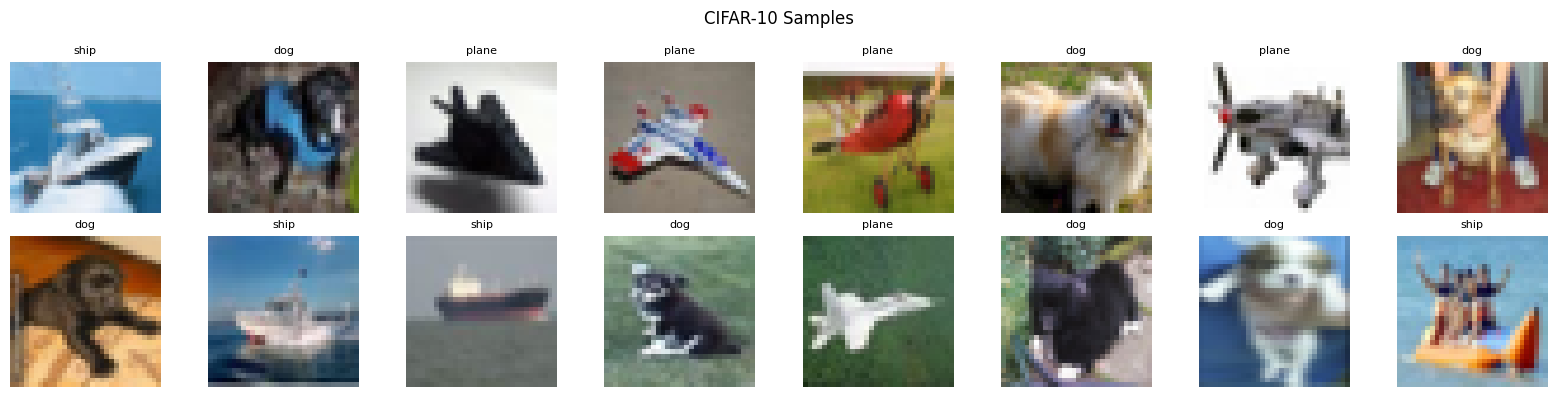

In [18]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Filter dataset to only include: plane (0), dog (5), ship (8)
# All classes are ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
target_classes = {0: 0, 5: 1, 8: 2} # Original label -> New label (0, 1, 2)
CLASSES = ('plane', 'dog', 'ship')

def filter_dataset(dataset, max_samples=None):
    indices = [i for i, target in enumerate(dataset.targets) if target in target_classes]
    # Slice the indices to take only a smaller sample for fast debugging
    if max_samples:
        indices = indices[:max_samples]
    dataset.data = dataset.data[indices]
    dataset.targets = [target_classes[dataset.targets[i]] for i in indices]
    return dataset

# Choosing out of 50_000 samples for training and 10_000 samples for testing
max_train_samples = 10000
max_test_samples = 2000
train_dataset = filter_dataset(train_dataset, max_samples=max_train_samples)
test_dataset = filter_dataset(test_dataset, max_samples=max_test_samples)

config = VAEConfig()
torch.manual_seed(config.seed)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=config.batch_size, shuffle=False, num_workers=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    img, label = train_dataset[i]
    axes[i//8, i%8].imshow(img.permute(1,2,0))
    axes[i//8, i%8].set_title(CLASSES[label], fontsize=8)
    axes[i//8, i%8].axis('off')
plt.suptitle('CIFAR-10 Samples'); plt.tight_layout(); plt.show()

# The Model

**Encoder** (image → z distribution):
   Input image (3×32×32) → 4 conv layers with stride 2 → flatten → two linear heads: μ and log(σ²) [always positive]

**Reparameterize** (externalize the randomness/stochsticity from z to ε):
   z = μ + σ · ε,  where ε ~ N(0,1)

**Decoder** (z → image):
   z → linear → reshape → 4 **transposed** conv layers → output (3×32×32)

In [ ]:

class ConvVAE(nn.Module):

    def __init__(self, cfg: VAEConfig):
        super().__init__()
        C = cfg.base_channels  # 32
        self.cfg = cfg

        # ENCODER: 32x32 → 16x16 → 8x8 → 4x4 → 2x2 → flatten
        # Fixed numbers: kernel size=4, stride=2, padding=1 -> halves spatial dims each layer
        self.encoder = nn.Sequential(
            nn.Conv2d(cfg.in_channels, C,   4, 2, 1), nn.BatchNorm2d(C),   nn.LeakyReLU(0.2),  # → 16x16
            nn.Conv2d(C,   C*2, 4, 2, 1), nn.BatchNorm2d(C*2), nn.LeakyReLU(0.2),              # → 8x8
            nn.Conv2d(C*2, C*4, 4, 2, 1), nn.BatchNorm2d(C*4), nn.LeakyReLU(0.2),              # → 4x4
            nn.Conv2d(C*4, C*8, 4, 2, 1), nn.BatchNorm2d(C*8), nn.LeakyReLU(0.2),              # → 2x2
            nn.Flatten(), # Now h (in self.encode) is a flat 1D array of shape [batch_size, C*8*2*2]                                                                       # → C*8*2*2 = 1024
        )
        flat_dim = (C * 8)  * 2 * 2  # 1024
    

        # Two mappings: mu and log(sigma squared)
        self.fc_mu = nn.Linear(flat_dim, cfg.latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, cfg.latent_dim)

        # DECODER: reverse of encoder
        self.decoder_input = nn.Linear(cfg.latent_dim, flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(C*8, C*4, 4, 2, 1), nn.BatchNorm2d(C*4), nn.ReLU(),  # 2→4
            nn.ConvTranspose2d(C*4, C*2, 4, 2, 1), nn.BatchNorm2d(C*2), nn.ReLU(),  # 4→8
            nn.ConvTranspose2d(C*2, C,   4, 2, 1), nn.BatchNorm2d(C),   nn.ReLU(),  # 8→16
            nn.ConvTranspose2d(C, cfg.in_channels, 4, 2, 1), nn.Sigmoid()
            ,           # 16→32
        )
        

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # e**(0.5 * logvar) = sqrt(e**logvar) = sqrt(var) = sigma
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) # Takes the size of the eps to be the same as all (z, sigma, mu) and fills it with random N(0,1) values
        return mu + eps * std # now z is a multivariate N(mu, sigma squared) and differential

    def decode(self, z):
        h = self.decoder_input(z) # 128 → 1024
        h = h.view(-1, self.cfg.base_channels * 8, 2, 2) # Reshape to [batch_size, 256, 2, 2], -1 at batch_size is telling pytorch to figure the batch out
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar # Return the values used by the loss function

# The loss function
- It consists of two components: 
    - The reconstruction loss (represents the correctness of mapping of spicific instances of x with low to no smoothness/structure in latent space z interpolation)
    - The KL Divergence loss (to measure the distance between the 'variation introduction q_ϕ' distribution and the actual z distribution, with low emphasis on reconstruction)

In [20]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    """
    β is the knob:
      β small -> reconstruction dominates -> sharp recons, unstructured latent space
      β large -> KL dominates -> blurry recons, well-structured latent space
    """
    # MSE for continuous RGB imagery 
    recon = F.mse_loss(x_recon, x, reduction='sum') / x.shape[0]
    # The analytical form of KL with a standard normal prior 
    # -1/2 * sum(1 + log(sigma^2) - mu^2 - sigma^2) ******averaged over batch*********
    kl    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.shape[0]
    return recon + beta * kl, recon, kl # Include recon and kl as well for history tracking

# Combining the pieces together (the beaty of the training loop in PyTorch)

In [21]:
def train_vae(cfg, verbose=True):
    # Prepare model, optimizer, and history tracking
    model = ConvVAE(cfg).to(device)
    # Optimizers algorithms comparison -> refer to my other notebook
    # In the training loop, they are associated with model parameters, not the loss function in the epochs
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    history = {'total': [], 'recon': [], 'kl': []}

    for epoch in range(cfg.epochs):
        # Now the real magic
        model.train() # Set the model to training mode -> especially we used batchnorm
        ep_total, ep_recon, ep_kl = 0, 0, 0
        pbar = tqdm(train_loader, desc=f'Ep {epoch+1}/{cfg.epochs}', disable=not verbose)
        for imgs, _ in pbar:
            imgs = imgs.to(device)
            x_recon, mu, logvar = model(imgs) # Returned by forward()
            loss, recon, kl = vae_loss(x_recon, imgs, mu, logvar, beta=cfg.beta)
            # for each batch, refresh the autoGrad (delete the grads of the previous one) -> perform one single backprobagation step (calculate the gradients automatically) 
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_total += loss.item(); ep_recon += recon.item(); ep_kl += kl.item()
            pbar.set_postfix(loss=f'{loss:.0f}', R=f'{recon:.0f}', KL=f'{kl:.0f}')

        n = len(train_loader)
        history['total'].append(ep_total/n)
        history['recon'].append(ep_recon/n)
        history['kl'].append(ep_kl/n)
    return model, history

# β  search
It's just for debugging and visualization purposes, not a core component
- It includes training a full VAE for each β value

In [22]:
beta_values = [0.1, 1.0, 5.0]
beta_models = {}
beta_histories = {}

for beta in beta_values:
    print(f"\n{'='*50}")
    print(f"Training with β = {beta}")
    print(f"{'='*50}")
    cfg = VAEConfig(beta=beta)
    m, h = train_vae(cfg)
    beta_models[beta] = m
    beta_histories[beta] = h
    torch.save(m.state_dict(), f'results/vae/model_beta{beta}.pt')


Training with β = 0.1


Ep 1/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 2/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 3/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 4/100:   0%|          | 0/157 [00:00<?, ?it/s]

...

Ep 96/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 97/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 98/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 99/100:   0%|          | 0/157 [00:00<?, ?it/s]

Ep 100/100:   0%|          | 0/157 [00:00<?, ?it/s]

# Compare Training Curves
#See how the loss components behave differently for each β.

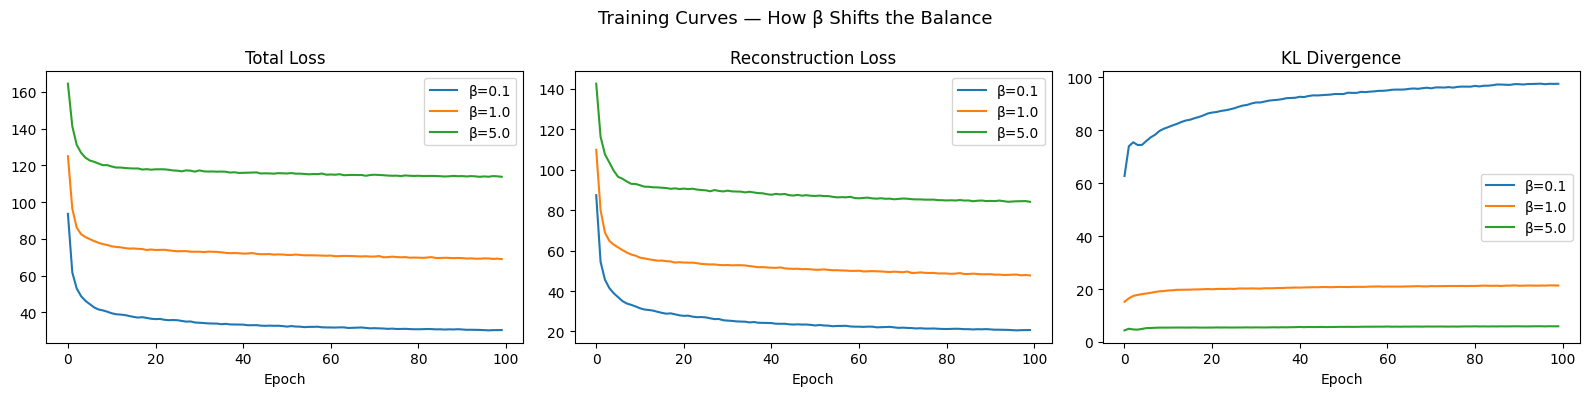

In [28]:
# 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for beta in beta_values:
    h = beta_histories[beta]
    axes[0].plot(h['total'], label=f'β={beta}')
    axes[1].plot(h['recon'], label=f'β={beta}')
    axes[2].plot(h['kl'],    label=f'β={beta}')
axes[0].set_title('Total Loss'); axes[1].set_title('Reconstruction Loss'); axes[2].set_title('KL Divergence')
for ax in axes: ax.legend(); ax.set_xlabel('Epoch')
plt.suptitle('Training Curves — How β Shifts the Balance', fontsize=13)
plt.tight_layout(); plt.savefig('results/vae/training_curves.png', dpi=150); plt.show()

# Comparing using x instances across β
Here we don't look for perfect reconstruction, but rather 

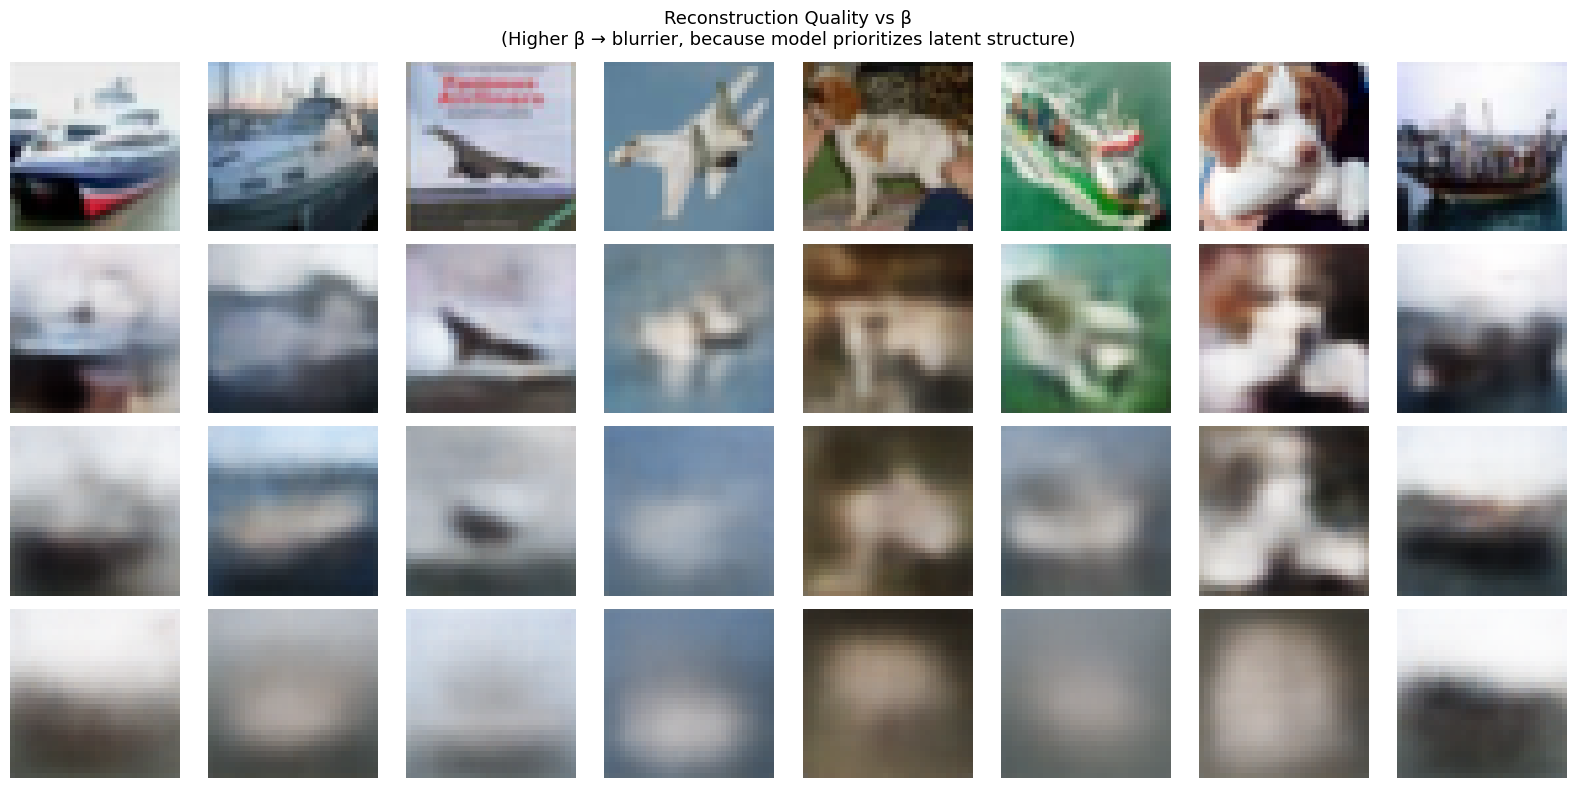

In [29]:
# in PyTorch -> dataloader is an iterable object -> being rapped in python iter() it's then a concrete iterator
        # -> next() gives us the next batch of data (imgs, labels) -> [0] to take the imgs and [:8] to take only the first 8 for visualization
test_imgs = next(iter(test_loader))[0][:8].to(device)

fig, axes = plt.subplots(len(beta_values)+1, 8, figsize=(16, 2*(len(beta_values)+1)))
# Row 0: originals
for i in range(8):
    axes[0,i].imshow(test_imgs[i].cpu().permute(1,2,0)); axes[0,i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=55)

# Rows 1-3: reconstructions for each β [0.1, 1.0, 5.0] (low to high)
for row, beta in enumerate(beta_values):
    beta_models[beta].eval()
    with torch.no_grad():
        recons, _, _ = beta_models[beta](test_imgs)
    for i in range(8):
        axes[row+1,i].imshow(recons[i].cpu().clamp(0,1).permute(1,2,0)); axes[row+1,i].axis('off')
    axes[row+1,0].set_ylabel(f'β={beta}', fontsize=10, rotation=0, labelpad=55)

plt.suptitle('Reconstruction Quality vs β\n(Higher β → blurrier, because model prioritizes latent structure)', fontsize=13)
plt.tight_layout(); plt.savefig('results/vae/beta_reconstructions.png', dpi=150); plt.show()


# Compare Generations Across β
Z instances from random z ~ N(0,1). Using the SAME z for all models (fair comparison).
Low β  → garbage (the latent space doesn't match N(0,1), so random z is out-of-distribution)
High β → better (the latent space was forced to match the prior)

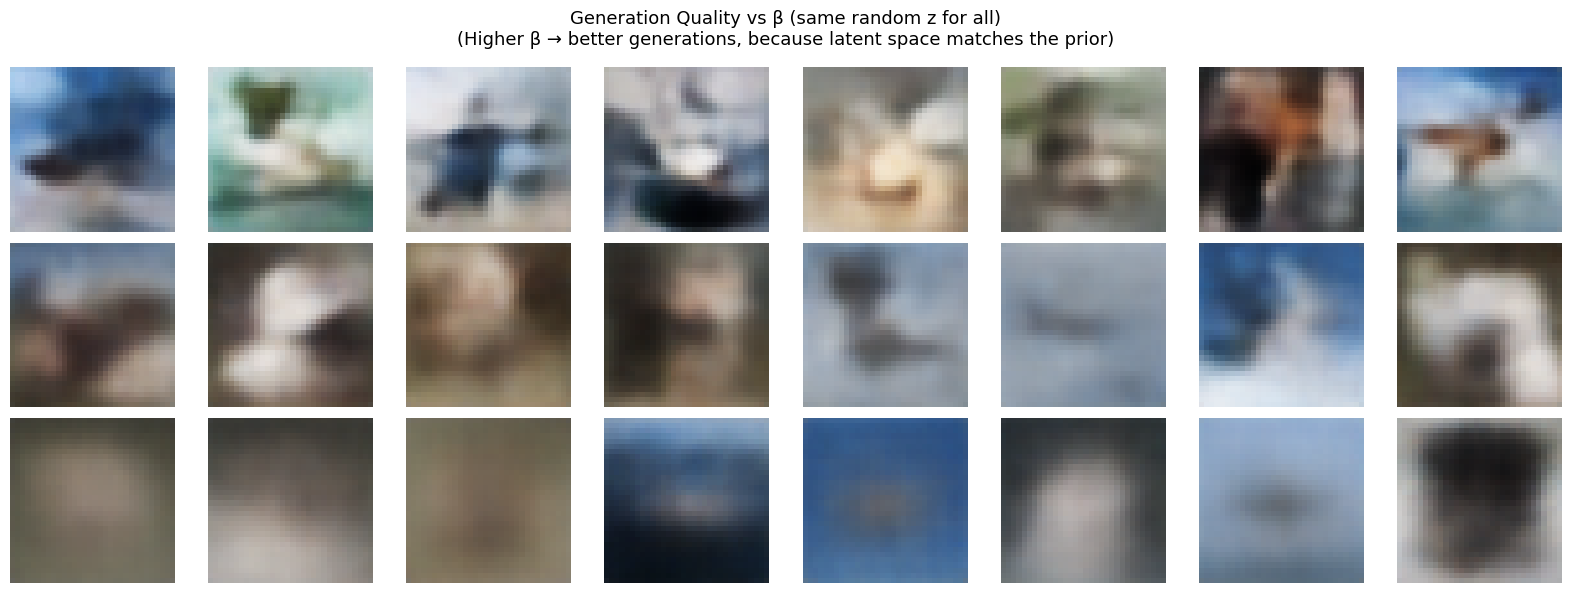

In [30]:
z_fixed = torch.randn(8, config.latent_dim).to(device)  # Same z for all models

fig, axes = plt.subplots(len(beta_values), 8, figsize=(16, 2*len(beta_values)))
for row, beta in enumerate(beta_values):
    beta_models[beta].eval()
    with torch.no_grad():
        gen = beta_models[beta].decode(z_fixed)
    for i in range(8):
        axes[row,i].imshow(gen[i].cpu().clamp(0,1).permute(1,2,0)); axes[row,i].axis('off')
    axes[row,0].set_ylabel(f'β={beta}', fontsize=10, rotation=0, labelpad=55)

plt.suptitle('Generation Quality vs β (same random z for all)\n(Higher β → better generations, because latent space matches the prior)', fontsize=13)
plt.tight_layout(); plt.savefig('results/vae/beta_generations.png', dpi=150); plt.show()


# t-SNE visualization for the high dimentional latent space

In [35]:
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

model_high_recon = beta_models[0.1]
model_high_recon.eval()

all_mu, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        mu, _ = model_high_recon.encode(imgs.to(device))
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu = np.concatenate(all_mu)[:5000]
all_labels = np.concatenate(all_labels)[:5000]

# Generate 3D t-SNE embeddings
mu_3d = TSNE(n_components=3, random_state=42, perplexity=30).fit_transform(all_mu)

# Map numeric labels to string class names for the legend
label_names = [CLASSES[int(label)] for label in all_labels]

# Create a DataFrame for an easier Plotly API experience
df = pd.DataFrame({
    'x': mu_3d[:, 0],
    'y': mu_3d[:, 1],
    'z': mu_3d[:, 2],
    'class': label_names
})

# Create the interactive 3D scatter plot
fig = px.scatter_3d(
    df, x='x', y='y', z='z',
    color='class',
    title='Interactive 3D t-SNE of Latent Space (μ vectors)',
    opacity=0.7,
    size_max=5
)

# Update layout for a cleaner look
fig.update_traces(marker=dict(size=4))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

In [36]:
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

model_high_kl = beta_models[5]
model_high_kl.eval()

all_mu, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        mu, _ = model_high_kl.encode(imgs.to(device))
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu = np.concatenate(all_mu)[:5000]
all_labels = np.concatenate(all_labels)[:5000]

# Generate 3D t-SNE embeddings
mu_3d = TSNE(n_components=3, random_state=42, perplexity=30).fit_transform(all_mu)

# Map numeric labels to string class names for the legend
label_names = [CLASSES[int(label)] for label in all_labels]

# Create a DataFrame for an easier Plotly API experience
df = pd.DataFrame({
    'x': mu_3d[:, 0],
    'y': mu_3d[:, 1],
    'z': mu_3d[:, 2],
    'class': label_names
})

# Create the interactive 3D scatter plot
fig = px.scatter_3d(
    df, x='x', y='y', z='z',
    color='class',
    title='Interactive 3D t-SNE of Latent Space (μ vectors)',
    opacity=0.7,
    size_max=5
)

# Update layout for a cleaner look
fig.update_traces(marker=dict(size=4))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()